In [4]:
df.columns

Index(['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream',
       'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1',
       'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6',
       'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships',
       'Projects', 'Workshops', 'Certifications', 'Publications',
       'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore',
       'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus',
       'IsAnomaly', 'Salary Package'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  str    
 2   City                50000 non-null  str    
 3   CollegeTier         50000 non-null  str    
 4   Stream              50000 non-null  str    
 5   Specialisation      50000 non-null  str    
 6   Hostel              50000 non-null  str    
 7   HistoryOfBacklogs   50000 non-null  str    
 8   SGPA_Sem1           50000 non-null  float64
 9   SGPA_Sem2           50000 non-null  float64
 10  SGPA_Sem3           50000 non-null  float64
 11  SGPA_Sem4           50000 non-null  float64
 12  SGPA_Sem5           50000 non-null  float64
 13  SGPA_Sem6           50000 non-null  float64
 14  SGPA_Sem7           50000 non-null  float64
 15  SGPA_Sem8           50000 non-null  float64
 16  CGPA           

In [7]:
df.isnull().sum()
df = df.drop_duplicates()

In [3]:
df.shape

(50000, 32)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
df["PlacementStatus"].value_counts()

PlacementStatus
1    32856
0    17144
Name: count, dtype: int64

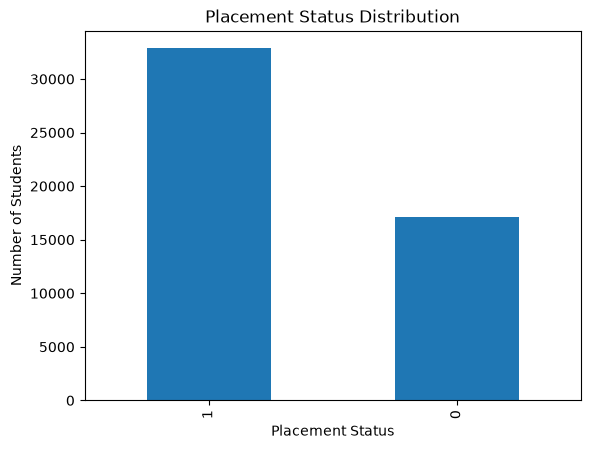

In [9]:
import matplotlib.pyplot as plt

df["PlacementStatus"].value_counts().plot(kind="bar")
plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

In [14]:
print(df.columns.tolist())

['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


In [15]:
X = df.drop("PlacementStatus", axis=1)
y = df["PlacementStatus"]

print(X.shape)
print(y.shape)

(50000, 30)
(50000,)


In [18]:
# Features (Input)
X = df.drop("PlacementStatus", axis=1)

# Target (Output)
y = df["PlacementStatus"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (50000, 30)
Target Shape: (50000,)


In [19]:
X.select_dtypes(include=["object"]).columns

C:\Users\tallu\AppData\Local\Temp\ipykernel_13576\1437029352.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include=["object"]).columns


Index(['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel',
       'HistoryOfBacklogs', 'CGPA_Tier'],
      dtype='str')

In [20]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
le = LabelEncoder()

# Convert all categorical columns into numbers
for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col])

# Display first five rows
X.head()

C:\Users\tallu\AppData\Local\Temp\ipykernel_13576\3892153879.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,IsAnomaly,Salary Package
0,1,0,1,2,3,0,0,6.02,6.54,6.52,...,2,0,66.7,2.2,49.4,47.8,0,1,0,0.00
1,0,8,1,2,1,1,1,5.84,5.12,5.34,...,1,0,48.2,2.4,26.7,25.8,0,1,0,0.00
2,1,7,1,4,1,1,0,4.91,5.29,5.49,...,1,0,73.8,2.8,67.7,41.5,0,1,0,3.89
3,1,5,0,0,0,0,0,7.67,8.03,8.08,...,2,0,69.8,2.7,66.9,48.0,0,2,0,8.37
4,1,9,1,4,1,1,0,8.14,8.97,8.36,...,4,1,73.1,2.1,71.7,61.7,1,0,0,18.99


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (40000, 30)
Testing Data : (10000, 30)


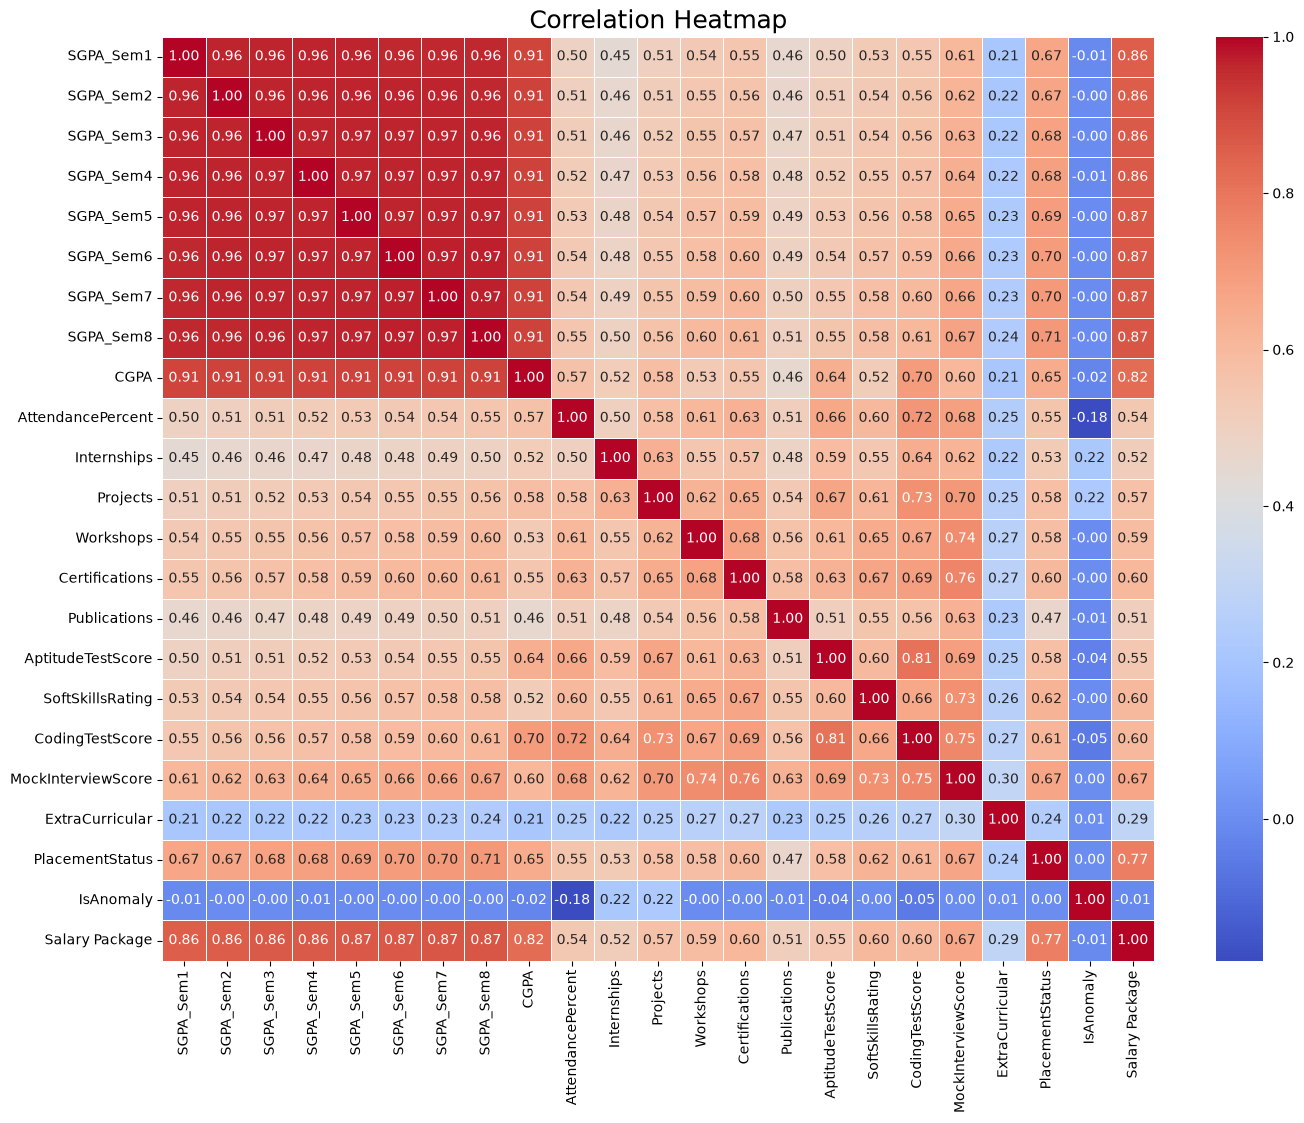

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Set figure size
plt.figure(figsize=(16, 12))

# Draw the heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

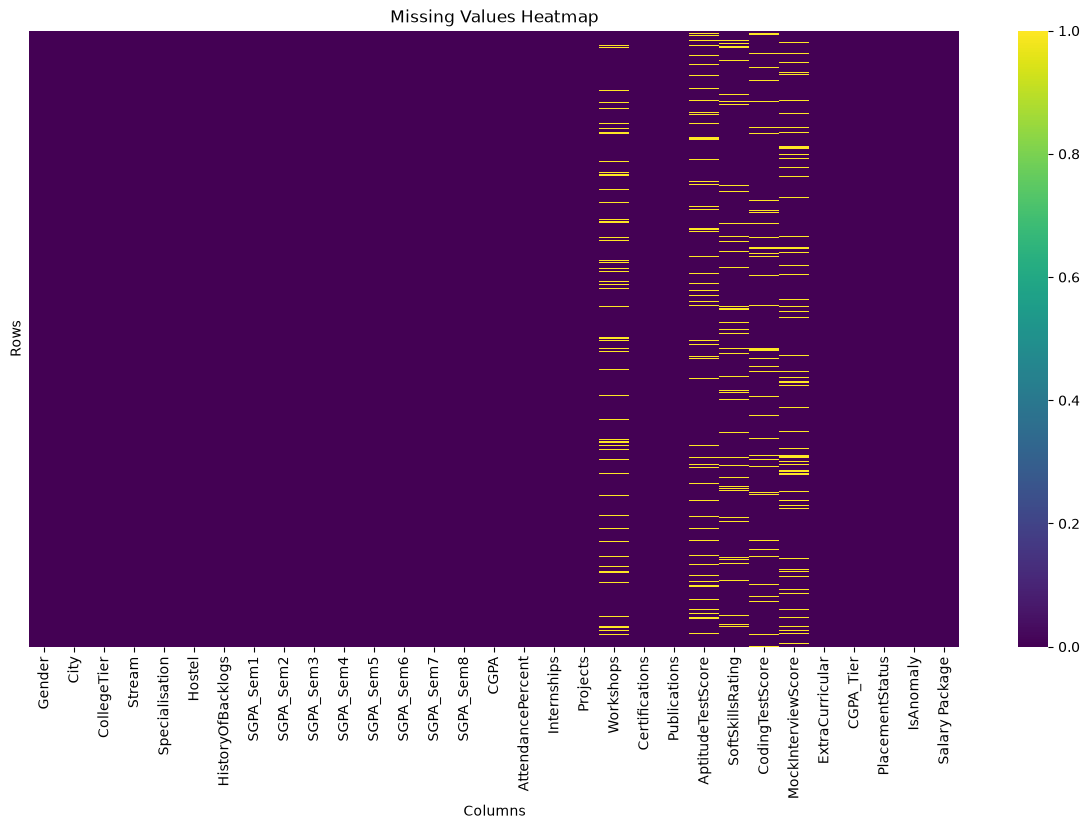

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap="viridis",
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()